sklearn.datasetsモジュールのload_iris関数を使ってアヤメのデータを読み込み、iris.dataを対象に主成分分析を行ってください。ただし、抽出する主成分の数は 2 とします。さらに第 2 主成分までのデータと目的変数（iris.target）との関係性をグラフ化などし考察してください。

In [30]:
# データ加工・処理・分析ライブラリ
import numpy as np
import numpy.random as random
import scipy as sp
from pandas import Series, DataFrame
import pandas as pd
# 可視化ライブラリ
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline
# 機械学習ライブラリ
import sklearn
# 小数第 3 位まで表示
%precision 3

'%.3f'

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [32]:
iris = sklearn.datasets.load_iris()

In [33]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [34]:
# 標準化
sc = StandardScaler()
X_std = sc.fit_transform(iris.data)
# 主成分分析
pca = PCA(n_components=2)
pca.fit(X_std)
X_pca = pca.transform(X_std)
# 表示
print('X_pca shape:{}'.format(X_pca.shape))
print('Explained variance ratio:{}'.format(pca.explained_variance_ratio_))

X_pca shape:(150, 2)
Explained variance ratio:[0.73  0.229]


In [35]:
# 列にラベルをつける、1 つ目が第 1 主成分、2 つ目が第 2 主成分
X_pca = pd.DataFrame(X_pca, columns=['pc1','pc2'])
# 上のデータに、目的変数（cancer.target）を紐づける、横に結合
X_pca = pd.concat([X_pca, pd.DataFrame(iris.target, columns=['target'])], axis=1)
# 正解ラベルで分ける
pca_0 = X_pca[X_pca['target']==0]
pca_1 = X_pca[X_pca['target']==1]
pca_2 = X_pca[X_pca['target']==2]

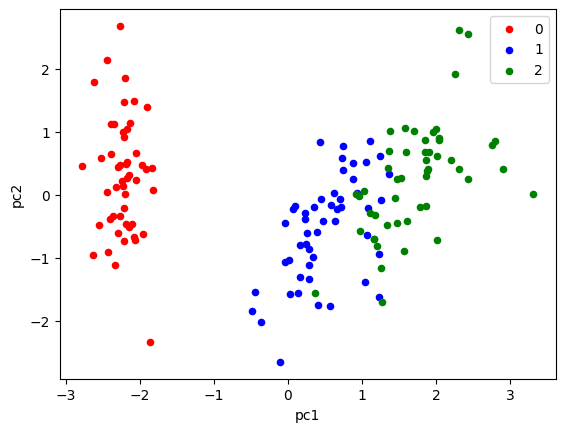

In [36]:

ax = pca_0.plot.scatter(x='pc1', y='pc2', color='red', label='0');
pca_1.plot.scatter(x='pc1', y='pc2', color='blue', label='1', ax=ax);
pca_2.plot.scatter(x='pc1', y='pc2', color='green', label='2', ax=ax);